El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [4]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones

In [5]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [6]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [7]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'

#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:
# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Entrada
inputs = Input(shape=X.shape[1:])

# === Bloque 1 ===
x1 = Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
x1 = Conv2D(16, (5, 5), padding='same', activation='relu')(x1)  # filtro 5x5

# === Bloque 2 ===
x2 = Conv2D(32, (3, 3), padding='same', activation='relu')(x1)
x2 = Conv2D(32, (3, 3), padding='same')(x2)

# 🔗 Conexión residual (concatenación)
res1 = Concatenate()([x1, x2])
res1 = Activation('relu')(res1)

# === Bloque 3 ===
x3 = Conv2D(64, (3, 3), padding='same', activation='relu')(res1)
x3 = Conv2D(64, (3, 3), padding='same')(x3)

# 🔗 Conexión residual (concatenación)
res2 = Concatenate()([res1, x3])
res2 = Activation('relu')(res2)

# === Bloque 4 (reducción de canales) ===
x4 = Conv2D(32, (3, 3), padding='same', activation='relu')(res2)
x4 = Conv2D(16, (3, 3), padding='same', activation='relu')(x4)

# 🔗 Conexión final (concatenación con la salida inicial)
res_final = Concatenate()([x4, x1])
res_final = Activation('relu')(res_final)

# === Salida ===
outputs = Conv2D(1, (3, 3), padding='same', activation='linear')(res_final)

# Crear modelo
model11 = Model(inputs, outputs)

# Compilación
model11.compile(
    optimizer='adam',
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo con concatenaciones residuales:")
model11.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath="modelo11.h5",
    monitor="loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Entrenamiento
print("Iniciando entrenamiento")
history11 = model11.fit(
    X, y,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history11.history['loss'][-1]:.4f}")

Resumen del modelo con concatenaciones residuales:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 480, 480,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 480, 480,  │      6,416 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 480, 480,  │      4,640 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 480, 480,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 480, 480,  │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 48)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 480, 480,  │          0 │ concatenate[0][0] │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 480, 480,  │     27,712 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 480, 480,  │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 480, 480,  │          0 │ activation[0][0], │
│ (Concatenate)       │ 112)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 480, 480,  │          0 │ concatenate_1[0]… │
│ (Activation)        │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 480, 480,  │     32,288 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 480, 480,  │      4,624 │ conv2d_6[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 480, 480,  │          0 │ conv2d_7[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 480, 480,  │          0 │ concatenate_2[0]… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 480, 480,  │        289 │ activation_2[0][… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,305 (477.75 KB)

 Trainable params: 122,305 (477.75 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1051.2898 - root_mean_squared_error: 0.0808
Epoch 190/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 971.5836 - root_mean_squared_error: 0.0809
Epoch 190: loss did not improve from 0.00653
93/93 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1050.2543 - root_mean_squared_error: 0.0808
Epoch 191/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 971.4000 - root_mean_squared_error: 0.0809
Epoch 191: loss did not improve from 0.00653
93/93 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1050.4651 - root_mean_squared_error: 0.0808
Epoch 192/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0066 - mean_absolute_percentage_error: 969.2676 - root_mean_squared_error: 0.0809
Epoch 192: loss did not improve from 0.00653
93/93 ━━━━━━━━━━━━━━━━━━━━ 205s 2s

93/93 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1043.7262 - root_mean_squared_error: 0.0808
Epoch 196/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 955.2297 - root_mean_squared_error: 0.0809
Epoch 196: loss did not improve from 0.00653
93/93 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1040.9105 - root_mean_squared_error: 0.0808
Epoch 197/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 952.5391 - root_mean_squared_error: 0.0809
Epoch 197: loss improved from 0.00653 to 0.00652, saving model to modelo11.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1037.9874 - root_mean_squared_error: 0.0808
Epoch 198/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 954.2971 - root_mean_squared_error: 0.0809
Epoch 198: loss improved from 0.00652 to 0.00652, saving model to modelo11.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1041.7625 - root_mean_squared_error: 0.0808
Epoch 199/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 953.1714 - root_mean_squared_error: 0.0808
Epoch 199: loss did not improve from 0.00652
93/93 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1039.4519 - root_mean_squared_error: 0.0808
Epoch 200/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 951.4875 - root_mean_squared_error: 0.0808
Epoch 200: loss improved from 0.00652 to 0.00651, saving model to modelo11.h5


93/93 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 1037.1056 - root_mean_squared_error: 0.0807
¡Entrenamiento completado!
Pérdida final: 0.0065


Valores de las metricas

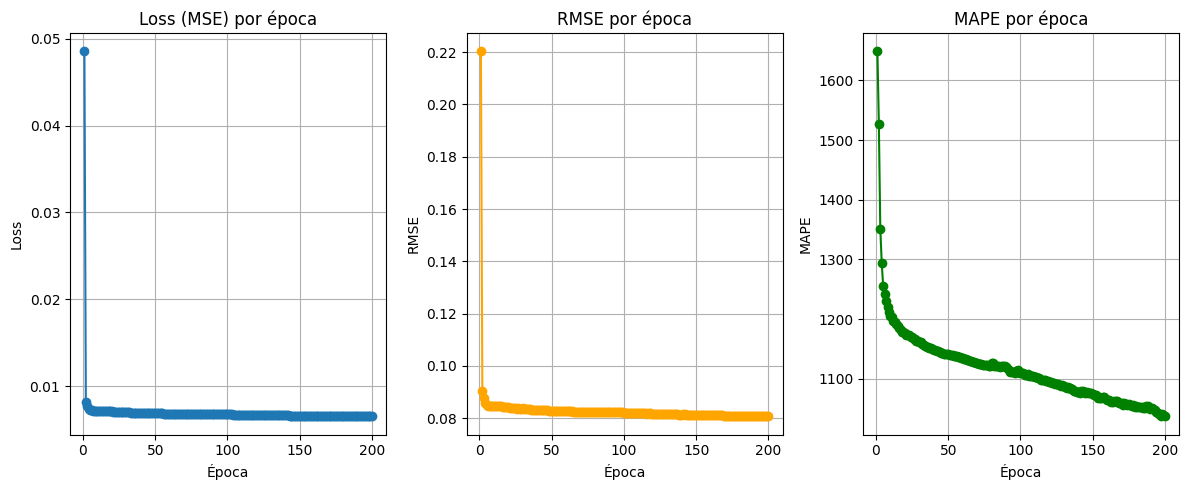

In [7]:
import matplotlib.pyplot as plt

# Extraer métricas del historial
loss = history11.history['loss']
rmse = history11.history['root_mean_squared_error']
mape = history11.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt

# Extraer métricas del historial de entrenamiento
loss = history11.history['loss']
rmse = history11.history['root_mean_squared_error']
mape = history11.history['mean_absolute_percentage_error']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o')
plt.title('Loss (MSE) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange')
plt.title('RMSE por época')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green')
plt.title('MAPE por época')
plt.xlabel('Época')
plt.ylabel('MAPE')
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'history11' is not defined

In [8]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError

# Cargar el modelo sin compilar
model11 = load_model("modelo11.h5", compile=False)

# Compilar nuevamente con las métricas correctas
model11.compile(
    optimizer='adam',
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

# Evaluar en el conjunto de entrenamiento
loss, rmse, mape = model11.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - loss: 0.0065 - mean_absolute_percentage_error: 995.8000 - root_mean_squared_error: 0.0804
Pérdida (MSE): 0.0065
RMSE: 0.0804
MAPE: 995.8000


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step


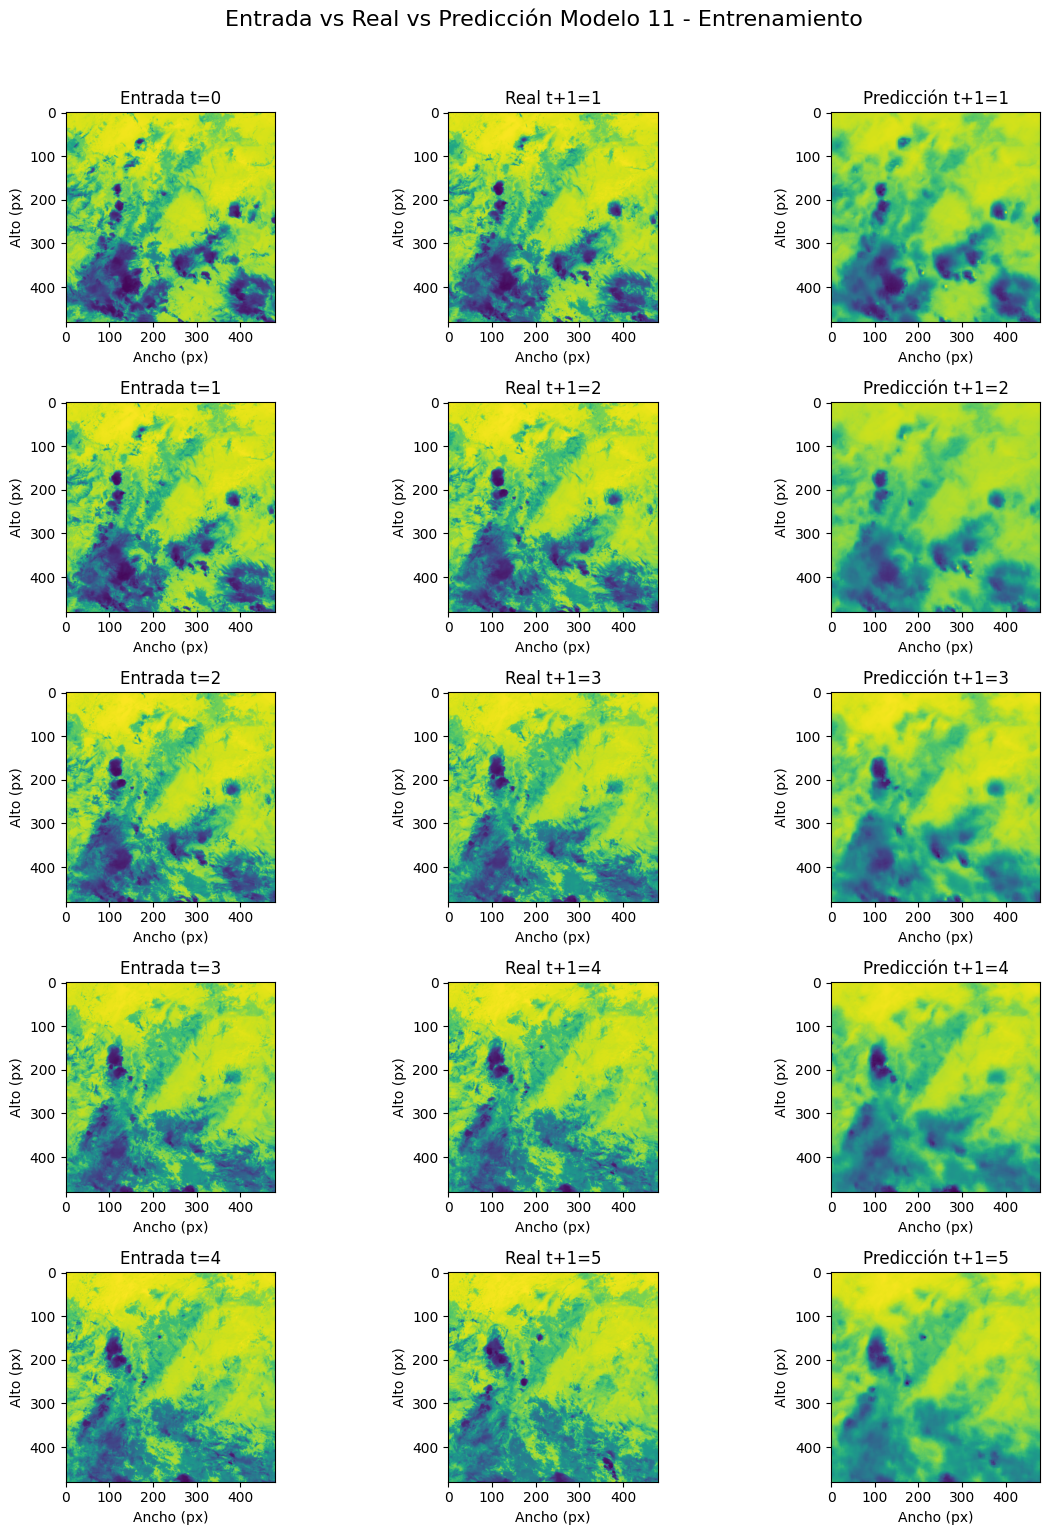

In [9]:
y_pred11 = model11.predict(X)  # Genera las predicciones
mostrar_resultados(
    X, y, y_pred11, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 11 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Validación

In [11]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [12]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model11.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.0159 - mean_absolute_percentage_error: 901.6469 - root_mean_squared_error: 0.1259
Pérdida (MSE): 0.0159
RMSE: 0.1259
MAPE: 901.6469


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


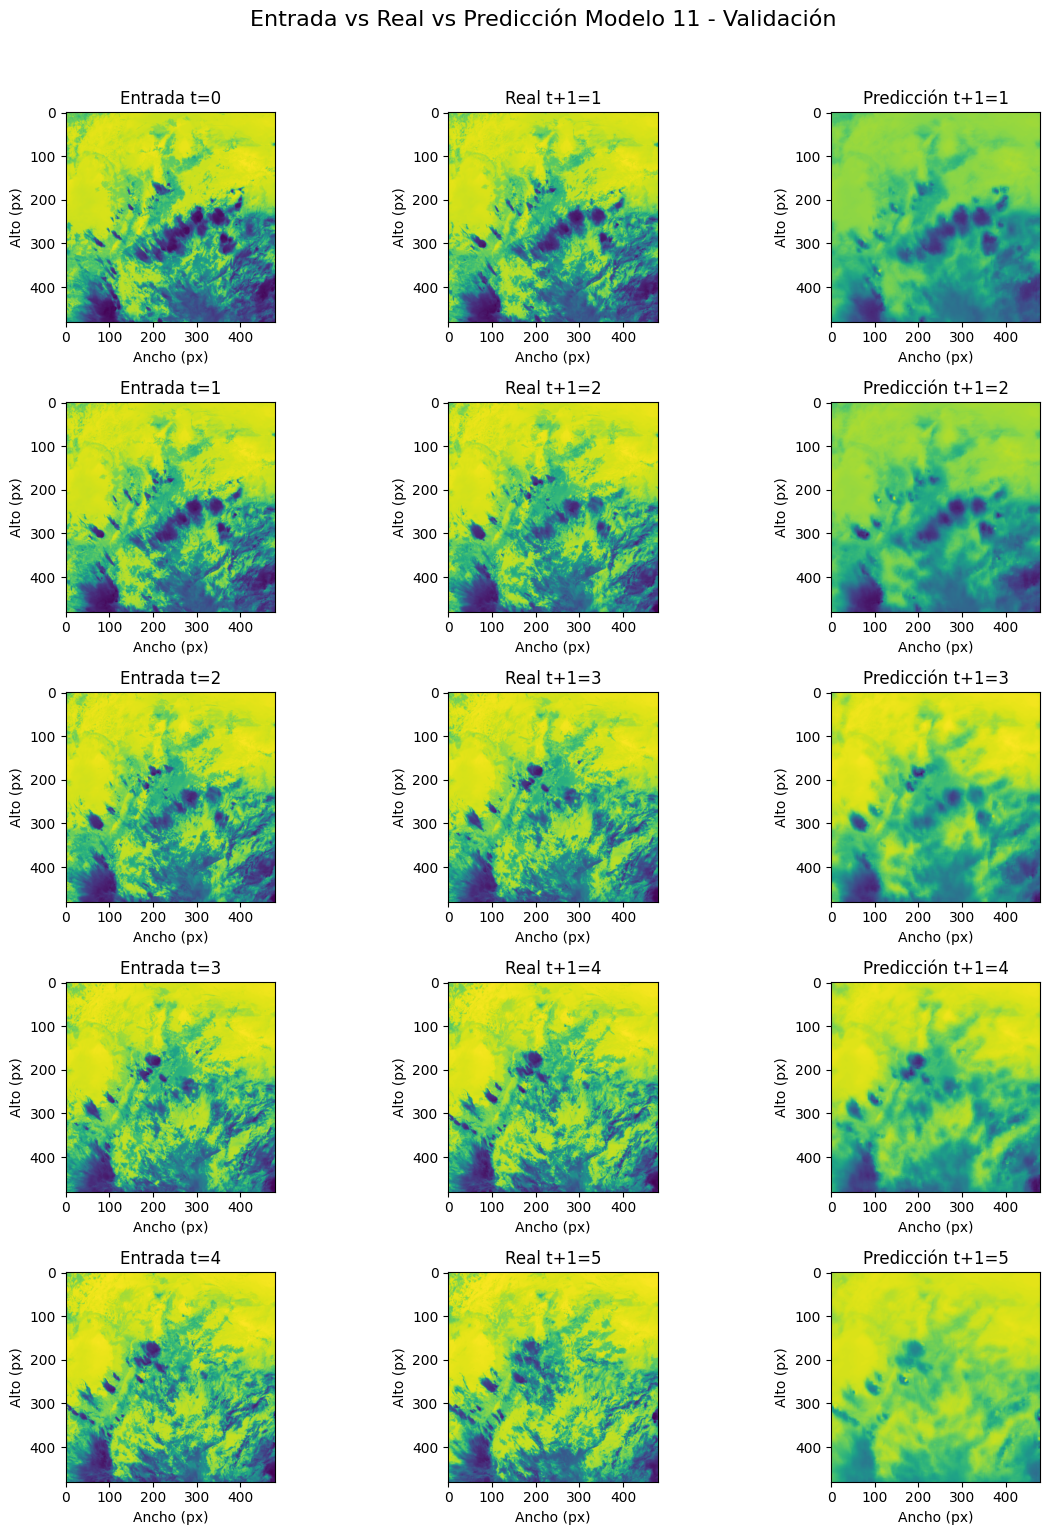

In [14]:
y_pred11_val = model11.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred11_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 11 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)